In [1]:
import sys

sys.path.insert(0, '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib')
print(sys.path)

['/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib', '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/playground', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python312.zip', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/lib-dynload', '', '/home/amunif/.local/lib/python3.12/site-packages', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages']


In [2]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import BinaryClassifier as BC
import HepG2Dataset as HG2D
import my_util

In [3]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [4]:
DATASET_PATH = "/group/pmc021/amunif/epi-thesis/workflow/07_deepchrome/dataset/E066"
markers = ['H3K4me3', 'H3K4me1','H3K36me3',  'H3K9me3', 'H3K27me3']

In [5]:
# Custom dataset for E066

class E066Dataset(Dataset):
    def __init__(self, total_samples, features, indexes):
        self.total_samples = total_samples
        self.features = features
        self.indexes = indexes

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        r1 = random.choice(self.indexes)
        r2 = random.choice(self.indexes)
        
        feature_1 = self.features[r1, 2]
        feature_2 = self.features[r2, 2]
        feature = np.concatenate((feature_1, feature_2), axis=0)
        
        val_1 = self.features[r1, 3]
        val_2 = self.features[r2, 3]

        y = 1 if val_1 > val_2 else 0
        
        return feature, y

In [6]:
# Declare  variables, working directory and dataset directory
MODE = 'E066'
NUM_EPOCHS = 100
START_EPOCH = 0
NUM_ITEMS = 1_000_000
BATCH_SIZE = 64
DROPOUT_RATE = 0.2

L1_lambda = 0.005
L2_lambda = 0.001
# L1_lambda = 0.0
# L2_lambda = 0.0

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
# DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', MODE, "model", f'{PREFIX}-checkpoint-{SUFFIX}.pt')

TEST_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'test', f"{PREFIX}-test-results-{SUFFIX}.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'train', f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'test', f"{PREFIX}-test-metrics-{SUFFIX}.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'img', 'roc', f"{PREFIX}-roc-{SUFFIX}.png")
IMAGE_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'img', 'train', f"{PREFIX}-ranking-{SUFFIX}.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', MODE, 'img', 'confusion_matrix', f"{PREFIX}-cm-{SUFFIX}.png")

INPUT_SIZE = 1000

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/E066/model/dol1l2-0.2-checkpoint-1000000-100-64-0.005-0.001.pt


# Read the Dataset

In [7]:
E066_w_histone_pl = pl.read_parquet(os.path.join(DATASET_PATH, 'E066_w_histone_pl.parquet'))

In [8]:
E066_w_histone_pl

gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]]
"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,1,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]"
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",52,100,"[10.55422, 10.55422, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,52.609,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]"
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,0.942,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.212,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",5,100,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.071,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [9]:
E066_w_histone_pl["E066"].describe()

statistic,value
str,f64
"""count""",19645.0
"""null_count""",0.0
"""mean""",45.584333
"""std""",913.103491
"""min""",0.0
"""25%""",0.115
"""50%""",2.423
"""75%""",10.843
"""max""",102156.0


In [10]:
# Add index to dataframe
E066_w_histone_pl = E066_w_histone_pl.with_row_index("index")
E066_w_histone_pl

index,gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone
u32,str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]]
0,"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,1,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]"
1,"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
2,"""ENSG00000000419""","[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",52,100,"[10.55422, 10.55422, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,52.609,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]"
3,"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
4,"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,0.942,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
19640,"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.212,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
19641,"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",5,100,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
19642,"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.071,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [11]:
zero_count = (E066_w_histone_pl["E066"] == 0.0).sum()
print(zero_count)
print(f"Zero value: {zero_count / len(E066_w_histone_pl) * 100:.2f}%")

2902
Zero value: 14.77%


In [12]:
# Combine all histones into single features
gene_features = E066_w_histone_pl.with_columns(
    pl.concat_list(markers).alias("combined_features")
)

gene_features

index,gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone,combined_features
u32,str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]],list[f64]
0,"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,1,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]","[0.0, 4.19024, … 0.0]"
1,"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
2,"""ENSG00000000419""","[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",52,100,"[10.55422, 10.55422, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,52.609,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]","[0.0, 0.0, … 0.0]"
3,"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
4,"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,0.942,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
19640,"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.212,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
19641,"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",5,100,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"
19642,"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.071,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[0.0, 0.0, … 0.0]"


In [13]:
# Select only index, gene_id, E066 value, and the combined features
gene_features_selected = gene_features.select(["index", "gene_id", "combined_features", "E066"])

In [14]:
gene_features_selected

index,gene_id,combined_features,E066
u32,str,list[f64],f64
0,"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",73.205
1,"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0.191
2,"""ENSG00000000419""","[0.0, 0.0, … 0.0]",52.609
3,"""ENSG00000000457""","[0.0, 0.0, … 0.0]",4.733
4,"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0.942
…,…,…,…
19640,"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0.212
19641,"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0.0
19642,"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0.071


In [15]:
# Convert to numpy array
gene_features_selected_np = gene_features_selected.to_numpy()

In [16]:
# Split train, test, validation by index
data_indices = np.arange(len(gene_features_selected_np))
print(data_indices)

[    0     1     2 ... 19642 19643 19644]


In [17]:
# First split: 80% train, 20% temporary (for test + validation)
train_idx, temp_idx = train_test_split(
    data_indices, 
    test_size=0.2, 
    random_state=42  # For reproducibility
)

In [18]:
# Second split: Split temp_idx into 50% test and 50% validation
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    random_state=42  # Same random_state for consistency
)

In [19]:
print(train_idx)
print(val_idx)
print(test_idx)

[ 1795  9363 14610 ...  5390   860 15795]
[11446 15912 16343 ...   251 15521   668]
[18530 11682  3062 ... 17579 15568 17851]


In [20]:
# Result: train_idx (80%), test_idx (10%), val_idx (10%)
print(f"Train indices: {len(train_idx)}")
print(f"Test indices: {len(test_idx)}")
print(f"Validation indices: {len(val_idx)}")

Train indices: 15716
Test indices: 1965
Validation indices: 1964


# Experiment

In [21]:
# Define the dataset
train_dataset = E066Dataset(int(0.8 * NUM_ITEMS), gene_features_selected_np, train_idx)
val_dataset = E066Dataset(int(0.1 * NUM_ITEMS), gene_features_selected_np, val_idx)
test_dataset = E066Dataset(int(0.1 * NUM_ITEMS), gene_features_selected_np, test_idx)

In [22]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

800000
100000
100000


In [23]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [24]:
# Initialize model
if MODEL_MODE == "reg":
    model = BinaryClassifier(input_size=INPUT_SIZE).to(device)
elif MODEL_MODE == "do":
    model = BinaryClassifierDropOut(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE).to(device)
elif MODEL_MODE == "dol1l2":
    model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

In [25]:
model

BinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=1000, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [26]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [27]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    START_EPOCH = 0

In [28]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:
        
        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
        
    # # Adjust learning rate
    # scheduler.step()
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            
            if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
                outputs = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
            elif MODEL_MODE == "dol1l2":
                outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))

    # Adjust learning rate
    scheduler.step(val_loss)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')
    
    # Save the model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_aucs': train_aucs,
        'val_aucs': val_aucs,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'val_f1_scores': val_f1_scores,
    }, CHECKPOINT_NAME)

Epoch [1/100] - [TRAIN] Loss: 0.5478, Accuracy: 74.15%, AUC: 0.74 [VAL] Loss: 0.5256, Accuracy: 75.76%, Precision: 0.76, Recall: 0.73, F1-Score: 0.75, AUC: 0.76
Epoch [2/100] - [TRAIN] Loss: 0.5295, Accuracy: 75.42%, AUC: 0.75 [VAL] Loss: 0.5205, Accuracy: 75.73%, Precision: 0.77, Recall: 0.72, F1-Score: 0.74, AUC: 0.76
Epoch [3/100] - [TRAIN] Loss: 0.5238, Accuracy: 75.62%, AUC: 0.76 [VAL] Loss: 0.5143, Accuracy: 76.15%, Precision: 0.77, Recall: 0.72, F1-Score: 0.75, AUC: 0.76
Epoch [4/100] - [TRAIN] Loss: 0.5212, Accuracy: 75.74%, AUC: 0.76 [VAL] Loss: 0.5116, Accuracy: 76.37%, Precision: 0.77, Recall: 0.73, F1-Score: 0.75, AUC: 0.76
Epoch [5/100] - [TRAIN] Loss: 0.5164, Accuracy: 76.07%, AUC: 0.76 [VAL] Loss: 0.5116, Accuracy: 76.16%, Precision: 0.77, Recall: 0.73, F1-Score: 0.75, AUC: 0.76
Epoch [6/100] - [TRAIN] Loss: 0.5137, Accuracy: 76.15%, AUC: 0.76 [VAL] Loss: 0.5075, Accuracy: 76.36%, Precision: 0.77, Recall: 0.73, F1-Score: 0.75, AUC: 0.76
Epoch [7/100] - [TRAIN] Loss: 0.51

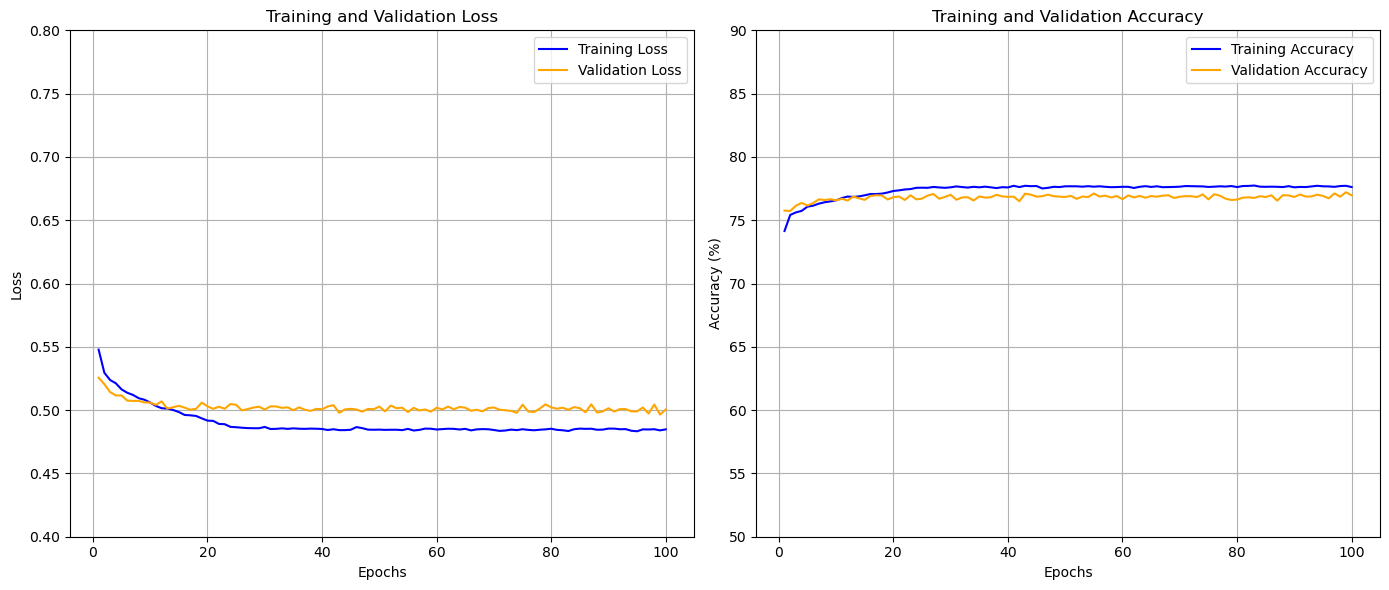

In [29]:
# Plot metrics
my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS, IMAGE_FILE)

In [30]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
        
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [31]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
cr = classification_report(test_true_labels, test_predictions)
cm = confusion_matrix(test_true_labels, test_predictions)

In [32]:
test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
AUC Score on test set: {test_auc_score:.2f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1_score:.4f}

Detailed Classification Report:
{cr}

Confusion Matrix:
{cm}
"""

print(test_output)

Accuracy Score on test set: 77.53 %
AUC Score on test set: 0.77
Precision: 0.7826
Recall: 0.7484
F1-Score: 0.7651

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.78     51097
           1       0.78      0.75      0.77     48903

    accuracy                           0.78    100000
   macro avg       0.78      0.77      0.77    100000
weighted avg       0.78      0.78      0.78    100000


Confusion Matrix:
[[40929 10168]
 [12306 36597]]



In [33]:
# Save the test output to text file
with open(TEST_FILE, 'w', newline = '') as text_file:
    text_file.write(test_output)

In [34]:
# Training metrics
experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)
experiment_pl.write_csv(TRAINING_FILE)

In [35]:
# Test output
test_results = {
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(TEST_RESULT_FILE)

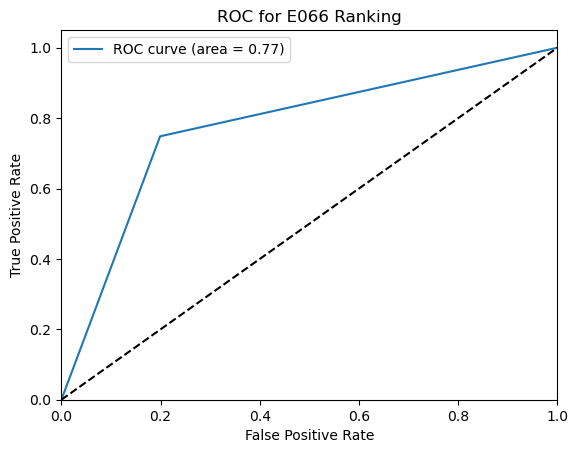

In [36]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for E066 Ranking')
plt.legend()

plt.savefig(ROC_FILE)

plt.show()

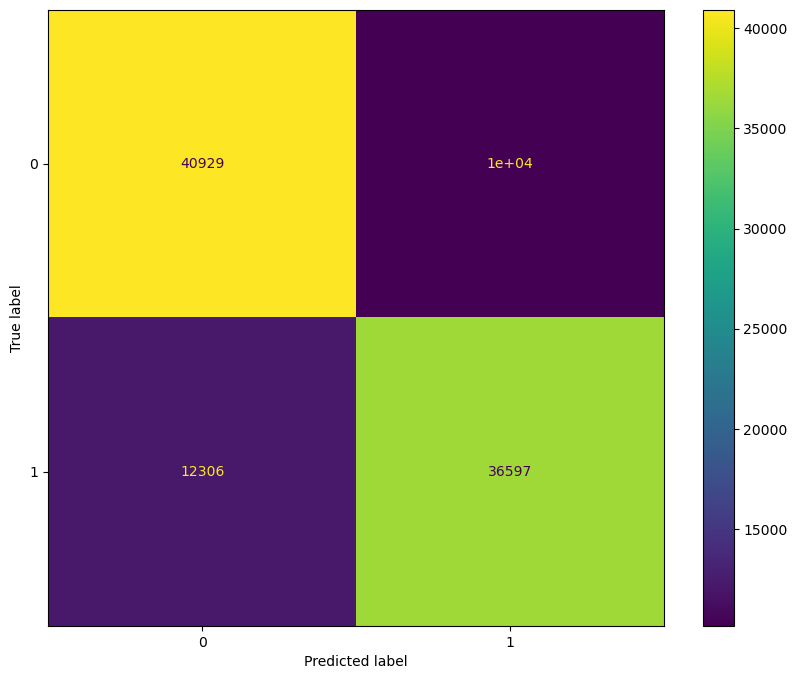

In [37]:
# Plot the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
cm_display.plot(ax=ax)
plt.savefig(CM_FILE)